# Dataset Preparation and Filtering

**Importing polars**

for lazy loading as the dataset is huge

In [1]:
import polars as pl
from datetime import date

* Loads the daily transaction dataset
* Loads the global target label dataset

In [2]:
daily = pl.read_parquet('../data/raw/chain/daily_filtered.parquet')
targets = pl.read_parquet('../data/raw/chain/targets_global.parquet')

**Explore the Daily and target dataset**
* Prints dataset shapes
* Prints data types
* Shows date range
* Displays scam class balance
* Shows how many addresses overlap between datasets

In [3]:
# Daily overview
print("\ndaily shape:", daily.shape)
print("\ndaily column types:", daily.schema)
print("\nDaily Date Range:", daily['day'].min(), "-", daily['day'].max())

# Targets overview
print("\ntargets shape:", targets.shape)
print("\ntargets schema:", targets.schema)


daily shape: (42946110, 31)

daily column types: Schema({'node_id': UInt64, 'address': String, 'day': Date, 'week': String, 'month': String, 'normal_sent_cnt': Int64, 'normal_recv_cnt': Int64, 'normal_total_cnt': Int64, 'normal_failed_cnt': Int64, 'normal_to_contract_cnt': Int64, 'normal_to_eoa_cnt': Int64, 'gas_used_sum': Int64, 'erc20_sent_cnt': Int64, 'erc20_recv_cnt': Int64, 'erc20_total_cnt': Int64, 'erc20_unique_tokens_sent': Int64, 'erc20_unique_tokens_recv': Int64, 'internal_out_cnt': Int64, 'internal_in_cnt': Int64, 'uniq_peers_cnt': Int64, 'uniq_contract_peers_cnt': Int64, 'uniq_eoa_peers_cnt': Int64, 'sessions_cnt': Int64, 'active_span_min': Int64, 'burst_max_tx_5m': Int64, 'eth_sent_sum': Decimal(precision=38, scale=9), 'eth_recv_sum': Decimal(precision=38, scale=9), 'eth_net_flow': Decimal(precision=38, scale=9), 'tx_fee_eth_sum': Decimal(precision=38, scale=9), 'internal_out_value_eth_sum': Decimal(precision=38, scale=9), 'internal_in_value_eth_sum': Decimal(precision=38

In [4]:
print("\nclass balance:", targets.group_by('is_scam').len())
print("\ncontract count", targets.group_by('is_contract').len())

scam_eoa = targets.filter((pl.col("is_scam") == 1) & (pl.col("is_contract") == 0))
print("\nScam EOA count (is_scam=1 & is_contract=0):", scam_eoa.height)

# Overlap of scam EOAs (is_scam=1 & is_contract=0) with daily data
scam_eoa_overlap = daily.select("address").unique().join(
    scam_eoa.select("address").unique(), on="address", how="inner")

print("\nOverlap scam EOA addresses with daily data:", scam_eoa_overlap["address"].n_unique())

print("\nunique addresses in targets:", targets['address'].n_unique())

# Cross-check overlap
overlap = daily.select('address').unique().join(
    targets.select('address').unique(), on='address', how='inner'
)
print("\noverlap addresses:", overlap['address'].n_unique())


class balance: shape: (2, 2)
┌─────────┬───────┐
│ is_scam ┆ len   │
│ ---     ┆ ---   │
│ i8      ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 60086 │
│ 1       ┆ 54653 │
└─────────┴───────┘

contract count shape: (2, 2)
┌─────────────┬───────┐
│ is_contract ┆ len   │
│ ---         ┆ ---   │
│ i8          ┆ u32   │
╞═════════════╪═══════╡
│ 1           ┆ 69698 │
│ 0           ┆ 45041 │
└─────────────┴───────┘

Scam EOA count (is_scam=1 & is_contract=0): 14982

Overlap scam EOA addresses with daily data: 12893

unique addresses in targets: 114739

overlap addresses: 85147


**Analyze date columns**

In [9]:
print(daily[['day', 'week', 'month']].head())

shape: (5, 3)
┌────────────┬──────────┬─────────┐
│ day        ┆ week     ┆ month   │
│ ---        ┆ ---      ┆ ---     │
│ date       ┆ str      ┆ str     │
╞════════════╪══════════╪═════════╡
│ 2017-07-28 ┆ 2017-W30 ┆ 2017-07 │
│ 2017-07-28 ┆ 2017-W30 ┆ 2017-07 │
│ 2017-07-28 ┆ 2017-W30 ┆ 2017-07 │
│ 2017-07-28 ┆ 2017-W30 ┆ 2017-07 │
│ 2017-07-28 ┆ 2017-W30 ┆ 2017-07 │
└────────────┴──────────┴─────────┘


**Create Filtered Files - scam**
* Converts Decimal columns to Float
* filter scam and eoa addresses
* keep only required columns
* filter datat start from 2017-1-1
* Filters target labels to match available daily data
* Saves both filtered outputs into /processed/chain/


In [3]:
# convert Decimal columns to Float64
decimal_cols = [
    'eth_sent_sum',
    'eth_recv_sum',
    'eth_net_flow',
    'tx_fee_eth_sum',
    'internal_out_value_eth_sum',
    'internal_in_value_eth_sum'
]

daily = daily.with_columns([
    pl.col(col).cast(pl.Float64) for col in decimal_cols
])

# Filter scam EOAs only (is_scam=1 AND is_contract=0)
scam_targets = targets.filter(
    (pl.col("is_scam") == 1) &
    (pl.col("is_contract") == 0)
)

# Join daily data with scam EOA targets
scam_daily = daily.join(
    scam_targets.select("address"),
    on="address",
    how="inner"
)

# Filter date range
scam_daily = scam_daily.filter(
    (pl.col("day") >= date(2017, 1, 1)) &
    (pl.col("day") <= date(2021, 11, 1))
)

# Keep only columns
keep_cols = [
    "address",
    "day",
    "normal_sent_cnt",
    "normal_recv_cnt",
    "normal_total_cnt",
    "eth_sent_sum",
    "eth_recv_sum",
    "eth_net_flow",
    "uniq_peers_cnt",
    "sessions_cnt",
    "active_span_min",
    "burst_max_tx_5m"
]

scam_daily = scam_daily.select(keep_cols)

# Filter scam_targets to only addresses present in scam_daily
scam_targets_filtered = scam_targets.join(
    scam_daily.select("address").unique(),
    on="address",
    how="inner"
)

# Save outputs
scam_daily.write_parquet(
    "../data/processed/chain/scam_daily_cleaned.parquet"
)

scam_targets_filtered.write_parquet(
    "../data/processed/chain/scam_targets_global.parquet"
)

print("\nSaved scam_daily_cleaned.parquet")
print("Saved scam_targets_global.parquet")



Saved scam_daily_cleaned.parquet
Saved scam_targets_global.parquet


# Data Preprocessing and Cleaning

In [1]:
import pandas as pd

In [2]:
scam_daily = pd.read_parquet('../data/processed/chain/scam_daily_cleaned.parquet')
scam_targets = pd.read_parquet('../data/processed/chain/scam_targets_global.parquet')

In [3]:
print("\nScam Daily Shape:", scam_daily.shape)
print("Unique Scam EOA Addresses (daily):",scam_daily["address"].nunique())
print("Scam Daily Date Range:",scam_daily["day"].min(),"-",scam_daily["day"].max())
print("\nScam Targets Shape:", scam_targets.shape)
print("Unique Scam EOA Addresses (targets):",scam_targets["address"].nunique())
print("\nScam Daily dtypes:")
print(scam_daily.dtypes)



Scam Daily Shape: (2906035, 12)
Unique Scam EOA Addresses (daily): 8020
Scam Daily Date Range: 2017-01-01 - 2021-11-01

Scam Targets Shape: (8020, 4)
Unique Scam EOA Addresses (targets): 8020

Scam Daily dtypes:
address              object
day                  object
normal_sent_cnt       int64
normal_recv_cnt       int64
normal_total_cnt      int64
eth_sent_sum        float64
eth_recv_sum        float64
eth_net_flow        float64
uniq_peers_cnt        int64
sessions_cnt          int64
active_span_min       int64
burst_max_tx_5m       int64
dtype: object


**Check for null values in scam daily filtered files**

In [4]:
scam_daily.isnull().values.any()

np.False_

**Check for missing days for an addresses**
* this will group days to address level
* validate whether each address has days from start to end of activity

In [5]:
scam_daily['day'] = pd.to_datetime(scam_daily['day'])

# Function to find missing days for each address
def find_missing_days(group):
    min_day = group['day'].min()
    max_day = group['day'].max()
    full_range = pd.date_range(min_day, max_day, freq='D')
    missing = full_range.difference(group['day'])
    return pd.Series({
        'missing_days': missing.tolist(),
        'num_missing_days': len(missing),
        'is_continuous': len(missing) == 0
    })

missing_days_df = scam_daily.groupby('address').apply(find_missing_days).reset_index()

missing_only_df = missing_days_df[missing_days_df['num_missing_days'] > 0]

print("Addresses with missing days:")
print(missing_only_df)

Addresses with missing days:
Empty DataFrame
Columns: [address, missing_days, num_missing_days, is_continuous]
Index: []


C:\Users\Nilesh\AppData\Local\Temp\ipykernel_26076\927686924.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_days_df = scam_daily.groupby('address').apply(find_missing_days).reset_index()


Plot the first appreance date of the scam addresses

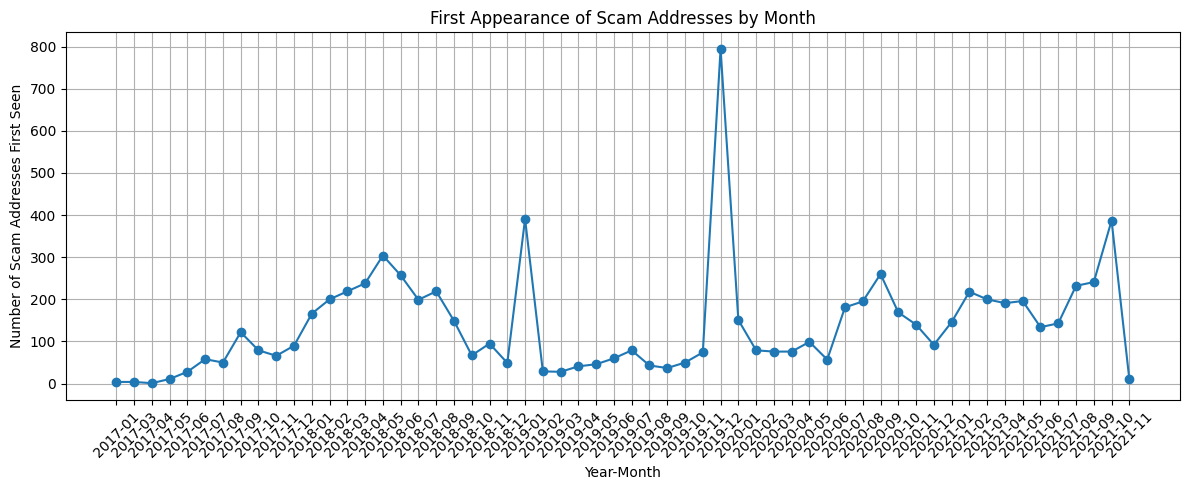

In [3]:
import matplotlib.pyplot as plt

scam_daily["day"] = pd.to_datetime(scam_daily["day"])

first_seen = (
    scam_daily
    .groupby("address")["day"]
    .min()
    .reset_index()
    .rename(columns={"day": "first_seen_date"})
)

first_seen["year_month"] = first_seen["first_seen_date"].dt.to_period("M")

monthly_counts = (
    first_seen
    .groupby("year_month")
    .size()
    .reset_index(name="num_scam_addresses")
)

monthly_counts["year_month"] = monthly_counts["year_month"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_counts["year_month"],
    monthly_counts["num_scam_addresses"],
    marker="o"
)

plt.title("First Appearance of Scam Addresses by Month")
plt.xlabel("Year-Month")
plt.ylabel("Number of Scam Addresses First Seen")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


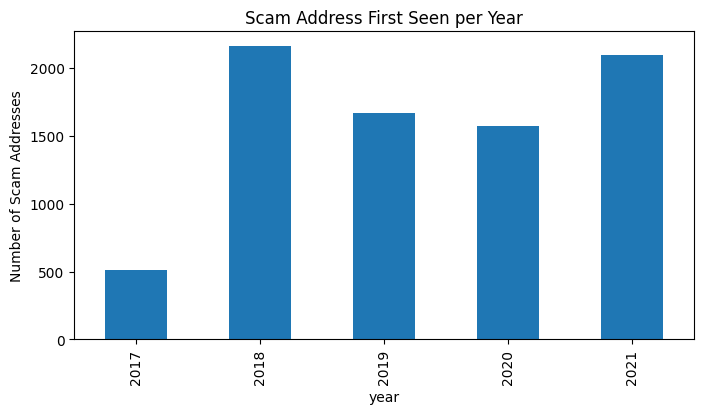

In [5]:
first_seen["year"] = first_seen["first_seen_date"].dt.year
yearly_counts = first_seen.groupby("year").size()

yearly_counts.plot(kind="bar", figsize=(8,4), title="Scam Address First Seen per Year")
plt.ylabel("Number of Scam Addresses")
plt.show()


#### **Scam types**
check and group the scam types that is available in the dataset

In [ ]:
import pandas as pd

In [2]:
scam_targets = pd.read_parquet('../data/processed/chain/scam_targets_global.parquet')
addr_labels = pd.read_csv('../data/raw/chain/addr_labels_balanced.csv')

In [3]:
addr_labels = addr_labels[["address", "description"]]

scam_with_types = scam_targets.merge(
    addr_labels,
    on="address",
    how="left"
)

total_addresses = scam_with_types["address"].nunique()
print("Total scam addresses:", total_addresses)

scam_type_stats = (
    scam_with_types
    .groupby("description")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nScam type distribution:")
print(scam_type_stats)

missing_labels = scam_with_types["description"].isna().sum()
print("\nAddresses with missing scam type:", missing_labels)

Total scam addresses: 8020

Scam type distribution:
                                            description  count
4724                                           Scamming   1791
4672                                           Phishing    474
5699  XRP phishing website (ripple.com.pt) that got ...     19
5707                                           phishing     18
85                          Fake Whalesburg ICO support      6
...                                                 ...    ...
5705       desire.finance: Deployer; etherscan reported      1
5706  fake ICO address for 0x via Slack Bot / DM. Li...      1
0                                             AFKSystem      1
5708                                   xToken Exploiter      1
45                    Cryptopia: Hack 6; Cryptopia Hack      1

[5710 rows x 2 columns]

Addresses with missing scam type: 1


In [5]:
addr_labels = addr_labels[["address", "description"]]

scam_with_types = scam_targets.merge(
    addr_labels,
    on="address",
    how="left"
)

total_addresses = scam_with_types["address"].nunique()
print("Total scam addresses:", total_addresses)


def map_scam_category(desc):
    if pd.isna(desc):
        return "Unknown"
    d = desc.lower()
    if "phish" in d:
        return "Phishing"
    elif "rug" in d:
        return "Rug Pull"
    elif "giveaway" in d:
        return "Giveaway Scam"
    elif "hack" in d:
        return "Hack / Exploit"
    elif "exploit" in d:
        return "Hack / Exploit"
    elif "ico" in d:
        return "Fake ICO"
    elif "impersonat" in d:
        return "Impersonation"
    else:
        return "Other"

scam_with_types["scam_category"] = scam_with_types["description"].apply(map_scam_category)

category_stats = (
    scam_with_types
    .groupby("scam_category")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(category_stats)



Total scam addresses: 8020
    scam_category  count
2  Hack / Exploit   3310
4        Phishing   2834
3           Other   1859
0        Fake ICO     11
5        Rug Pull      4
1   Giveaway Scam      1
6         Unknown      1
